In [23]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
dataset = pd.read_parquet("../data/processed/cleaned_dataset.parquet")
df = pd.DataFrame(dataset)
df.head()

,id,year,title,abstract,category,period
0,0704.1274,2007,parametric learning and monte carlo optimization,"[uncovers, explores, close, relationship, mont...",cs.lg,2005-2009
1,0704.2010,2007,a study of structural properties on profiles hmms,"[motivation, profile, hidden, markov, model, p...",cs.ai,2005-2009
2,0704.3433,2007,bayesian approach to rough set,"[proposes, approach, training, rough, model, b...",cs.ai,2005-2009
3,0704.3515,2007,comparing robustness of pairwise and multiclas...,"[noise, corruption, variation, face, image, se...",cs.ai,2005-2009
4,0704.3708,2007,network statistics on early english syntax: st...,"[includes, reflection, role, network, english,...",cs.cl,2005-2009


In [9]:
df['abstract'][0]

array(['uncovers', 'explores', 'close', 'relationship', 'monte', 'carlo',
       'optimization', 'parametrized', 'integral', 'mco', 'parametric',
       'machine', 'learning', 'blackbox', 'oracle', 'optimization',
       'make', 'four', 'contribution', 'prove', 'mco', 'mathematically',
       'identical', 'broad', 'class', 'problem', 'identity',
       'potentially', 'provides', 'application', 'domain', 'broadly',
       'applicable', 'technique', 'mco', 'second', 'introduce',
       'immediate', 'sampling', 'version', 'probability', 'collective',
       'algorithm', 'blackbox', 'optimization', 'immediate', 'sampling',
       'transforms', 'original', 'mco', 'accordingly', 'combining',
       'contribution', 'apply', 'technique', 'third', 'contribution',
       'validate', 'improving', 'demonstrating', 'cross', 'validation',
       'bagging', 'improve', 'immediate', 'sampling', 'finally',
       'conventional', 'mco', 'procedure', 'ignore', 'relationship',
       'sample', 'point', 'lo

In [37]:
print(df.shape)

(24806, 6)


In [36]:
# Add this after Cell 5 (the cleaning cell)
# Your parquet already has cleaned data so this is just 
# creating the analysis window

df_analysis = df[df['year'].between(2007, 2021)].copy()
df_analysis = df_analysis.reset_index(drop=True)

print(f"Analysis window: {len(df_analysis)} papers")
print(df_analysis['year'].value_counts().sort_index())

Analysis window: 24314 papers
year
2007      68
2008      96
2009     134
2010     237
2011     449
2012     481
2013    1061
2014     707
2015     875
2016    1403
2017    2208
2018    2512
2019    2539
2020    4079
2021    7465
Name: count, dtype: int64


## TF-IDF representation

In [13]:
df = df.dropna(subset=["abstract"])

df["abstract"] = df["abstract"].astype(str)

# Optional: remove very short abstracts
df = df[df["abstract"].str.split().str.len() > 20]

In [14]:
tfidf = TfidfVectorizer(
    max_features=5000,      # keep manageable
    stop_words="english",
    ngram_range=(1, 2)      # unigrams + bigrams
)

X_tfidf = tfidf.fit_transform(df["abstract"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (24806, 5000)


In [42]:
tfidf

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.

In [19]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['abbreviation' 'abductive' 'ability' 'ability learn' 'ability model'
 'ablation' 'able' 'able achieve' 'able learn' 'absa' 'absence' 'absolute'
 'absolute improvement' 'abstract' 'abstraction' 'abstractive'
 'abstractive summarization' 'abundant' 'abusive' 'academic']


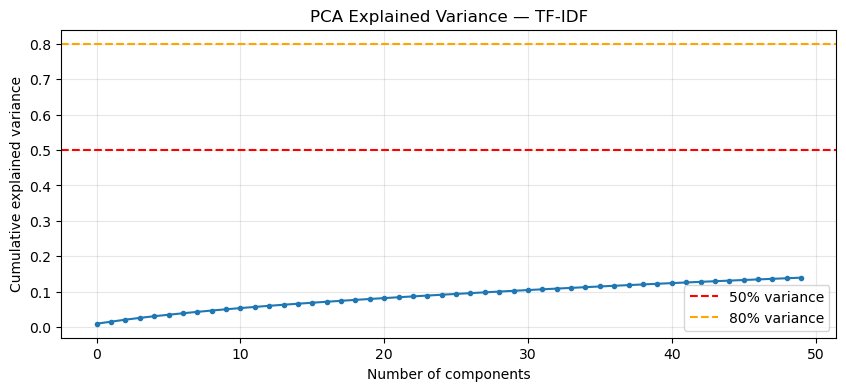

Components for 50% variance: 1
Components for 80% variance: 1


In [26]:
# First check how many components explain variance
pca_full = PCA(n_components=50)
tfidf_dense = X_tfidf.toarray()
pca_full.fit(tfidf_dense)

# Plot explained variance
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', markersize=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='50% variance')
plt.axhline(y=0.8, color='orange', linestyle='--', label='80% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance — TF-IDF')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig("outputs/figures/pca_tfidf_explained_variance.png", dpi=150)
plt.show()

print(f"Components for 50% variance: {np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.5) + 1}")
print(f"Components for 80% variance: {np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.8) + 1}")

In [29]:
# Check what words load most strongly on PC1
feature_names = tfidf.get_feature_names_out()
pc1_loadings = pca_full.components_[0]
pc2_loadings = pca_full.components_[1]

# Top words driving PC1
top_pc1 = pd.Series(pc1_loadings, index=feature_names).nlargest(15)
top_pc2 = pd.Series(pc2_loadings, index=feature_names).nlargest(15)

print("Top words on PC1:")
print(top_pc1)
print("\nTop words on PC2:")
print(top_pc2)

Top words on PC1:
language               0.352241
word                   0.240393
translation            0.237138
model                  0.193361
sentence               0.159996
text                   0.139826
task                   0.138773
english                0.119693
corpus                 0.112783
machine translation    0.102695
language model         0.100697
embeddings             0.090536
trained                0.087419
pre                    0.086735
multilingual           0.085437
dtype: float64

Top words on PC2:
translation            0.402609
language               0.181757
machine translation    0.166322
agent                  0.150040
nmt                    0.140951
machine                0.121304
english                0.112419
algorithm              0.104019
game                   0.089248
policy                 0.085120
neural machine         0.081044
resource               0.079759
parallel               0.067686
action                 0.063289
decision            

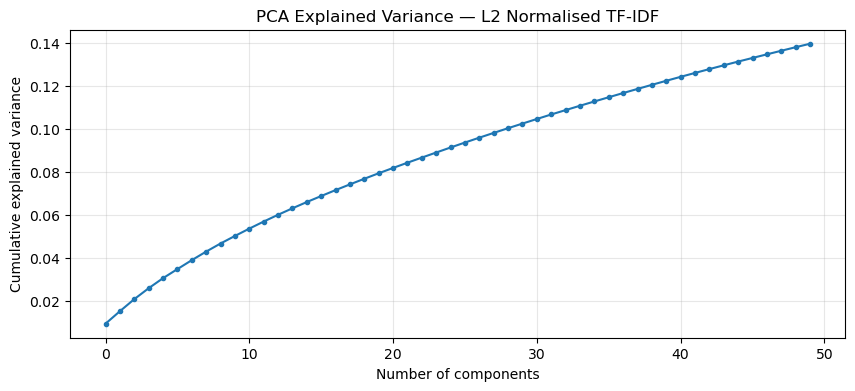

Components for 50% variance: 1
Components for 80% variance: 1


In [32]:
from sklearn.preprocessing import normalize

tfidf_normalised = normalize(X_tfidf, norm='l2')
tfidf_dense_norm = tfidf_normalised.toarray()

pca_norm = PCA(n_components=50, random_state=42)
pca_norm.fit(tfidf_dense_norm)

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca_norm.explained_variance_ratio_), marker='o', markersize=3)
plt.title('PCA Explained Variance — L2 Normalised TF-IDF')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Components for 50% variance: {np.argmax(np.cumsum(pca_norm.explained_variance_ratio_) >= 0.5) + 1}")
print(f"Components for 80% variance: {np.argmax(np.cumsum(pca_norm.explained_variance_ratio_) >= 0.8) + 1}")

In [39]:
from sklearn.decomposition import PCA

# Refit on df_analysis
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english", 
    ngram_range=(1, 2)
)

X_tfidf_analysis = tfidf.fit_transform(df_analysis['abstract'])
tfidf_dense = X_tfidf_analysis.toarray()

pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(tfidf_dense)

df_analysis = df_analysis.copy()
df_analysis['pca_tfidf_x'] = coords[:, 0]
df_analysis['pca_tfidf_y'] = coords[:, 1]

print(f"Variance explained: PC1={pca_2d.explained_variance_ratio_[0]:.3f}, PC2={pca_2d.explained_variance_ratio_[1]:.3f}")
print(f"Columns now: {df_analysis.columns.tolist()}")

Variance explained: PC1=0.010, PC2=0.006
Columns now: ['id', 'year', 'title', 'abstract', 'category', 'period', 'pca_tfidf_x', 'pca_tfidf_y']


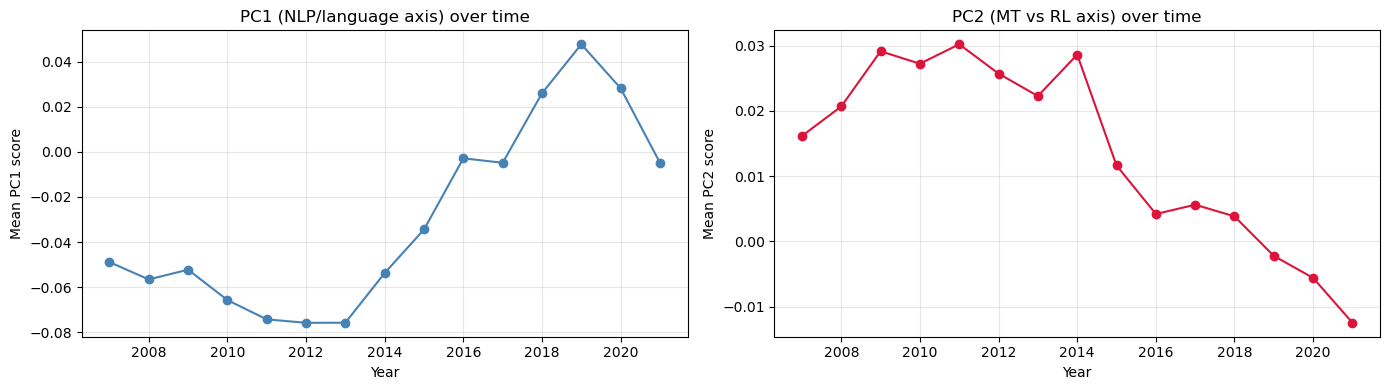

In [41]:
# Check centroid movement along each PC separately
centroids = df_analysis.groupby('year')[['pca_tfidf_x', 'pca_tfidf_y']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PC1 over time — NLP axis
axes[0].plot(centroids.index, centroids['pca_tfidf_x'], marker='o', color='steelblue')
axes[0].set_title('PC1 (NLP/language axis) over time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean PC1 score')
axes[0].grid(True, alpha=0.3)

# PC2 over time — MT vs RL axis  
axes[1].plot(centroids.index, centroids['pca_tfidf_y'], marker='o', color='crimson')
axes[1].set_title('PC2 (MT vs RL axis) over time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean PC2 score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("outputs/figures/pc1_pc2_over_time.png", dpi=150)
plt.show()

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_7475/3866823529.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(years))
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_7475/3866823529.py:51: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


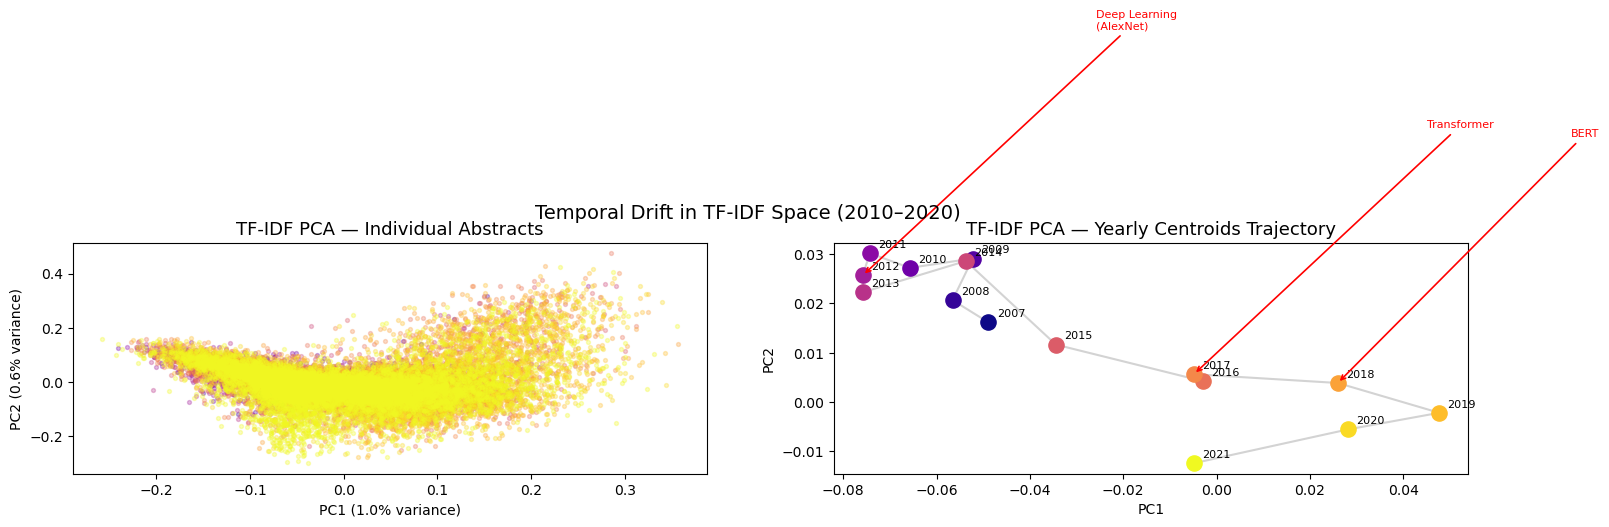

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(18, 3))

years = sorted(df_analysis['year'].unique())
cmap = cm.get_cmap('plasma', len(years))
year_to_color = {year: cmap(i) for i, year in enumerate(years)}

# Plot 1 — individual abstracts coloured by year
ax = axes[0]
for year in years:
    mask = df_analysis['year'] == year
    ax.scatter(
        df_analysis.loc[mask, 'pca_tfidf_x'],
        df_analysis.loc[mask, 'pca_tfidf_y'],
        c=[year_to_color[year]],
        alpha=0.3, s=8, label=str(year)
    )
ax.set_title('TF-IDF PCA — Individual Abstracts', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')

# Plot 2 — yearly centroids with trajectory line
ax = axes[1]
centroids_tfidf = df_analysis.groupby('year')[['pca_tfidf_x', 'pca_tfidf_y']].mean()

ax.plot(centroids_tfidf['pca_tfidf_x'], centroids_tfidf['pca_tfidf_y'],
        color='lightgray', linewidth=1.5, zorder=1)

for year in years:
    x, y = centroids_tfidf.loc[year]
    color = year_to_color[year]
    ax.scatter(x, y, c=[color], s=120, zorder=2)
    ax.annotate(str(year), (x, y), textcoords="offset points",
                xytext=(6, 4), fontsize=8)

# Annotate known paradigm shifts
paradigm_shifts = {2012: 'Deep Learning\n(AlexNet)', 2017: 'Transformer', 2018: 'BERT'}
for year, label in paradigm_shifts.items():
    if year in centroids_tfidf.index:
        x, y = centroids_tfidf.loc[year]
        ax.annotate(label,
                    xy=(x, y),
                    xytext=(x + 0.05, y + 0.05),
                    fontsize=8, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax.set_title('TF-IDF PCA — Yearly Centroids Trajectory', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

plt.suptitle('Temporal Drift in TF-IDF Space (2010–2020)', fontsize=14, y=1.01)
plt.tight_layout()
# plt.savefig("outputs/figures/pca_tfidf_trajectory.png", dpi=150, bbox_inches='tight')
plt.show()

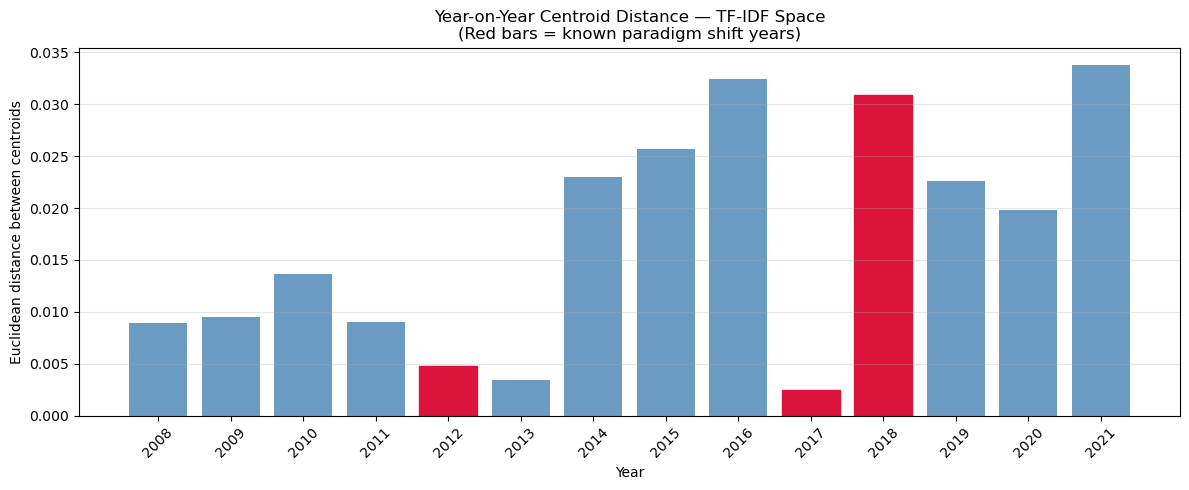


Largest year-on-year shifts:
   year_transition  distance
13       2020-2021  0.033744
8        2015-2016  0.032402
10       2017-2018  0.030852


In [48]:
# Calculate year-on-year centroid movement
centroid_distances = []
for i in range(1, len(years)):
    y1, y2 = years[i-1], years[i]
    c1 = centroids_tfidf.loc[y1].values
    c2 = centroids_tfidf.loc[y2].values
    dist = np.linalg.norm(c2 - c1)
    centroid_distances.append({'year_transition': f"{y1}-{y2}", 'year': y2, 'distance': dist})

dist_df = pd.DataFrame(centroid_distances)

plt.figure(figsize=(12, 5))
bars = plt.bar(dist_df['year'], dist_df['distance'], color='steelblue', alpha=0.8)

# Highlight paradigm shift years
shift_years = [2012, 2017, 2018]
for i, row in dist_df.iterrows():
    if row['year'] in shift_years:
        bars[i].set_color('crimson')
        bars[i].set_alpha(1.0)

plt.xlabel('Year')
plt.ylabel('Euclidean distance between centroids')
plt.title('Year-on-Year Centroid Distance — TF-IDF Space\n(Red bars = known paradigm shift years)')
plt.xticks(dist_df['year'], rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig("outputs/figures/centroid_distance_tfidf.png", dpi=150)
plt.show()

print("\nLargest year-on-year shifts:")
print(dist_df.nlargest(3, 'distance')[['year_transition', 'distance']])

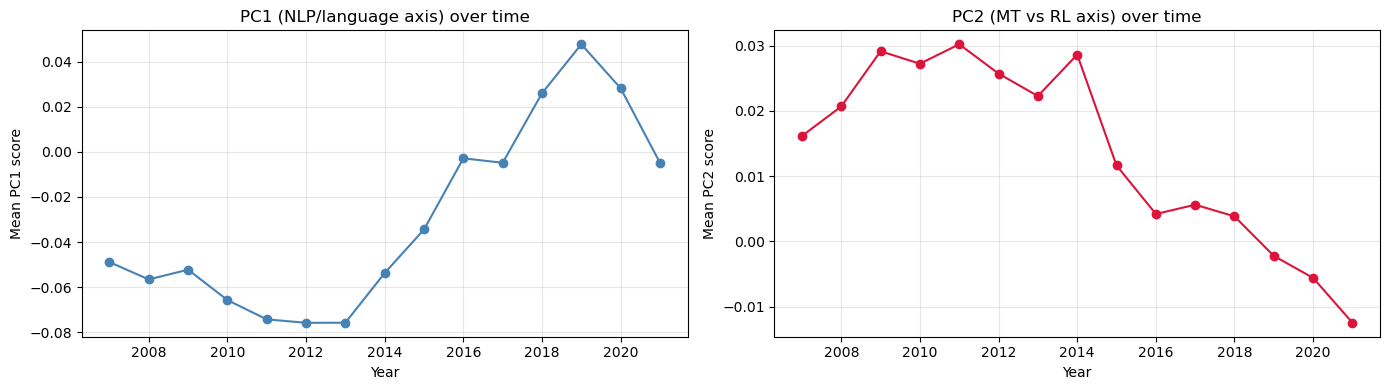

In [50]:
# Check centroid movement along each PC separately
centroids = df_analysis.groupby('year')[['pca_tfidf_x', 'pca_tfidf_y']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PC1 over time — NLP axis
axes[0].plot(centroids.index, centroids['pca_tfidf_x'], marker='o', color='steelblue')
axes[0].set_title('PC1 (NLP/language axis) over time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean PC1 score')
axes[0].grid(True, alpha=0.3)

# PC2 over time — MT vs RL axis  
axes[1].plot(centroids.index, centroids['pca_tfidf_y'], marker='o', color='crimson')
axes[1].set_title('PC2 (MT vs RL axis) over time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean PC2 score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("outputs/figures/pc1_pc2_over_time.png", dpi=150)
plt.show()

## Analysis
- PC1 increases over time — the corpus is becoming more NLP-vocabulary-heavy, consistent with Thread 1's theory→application finding since NLP is the more applied subfield

In [57]:
# Create cat_combo column from categories
def get_relevant_cats(cat_string):
    relevant = []
    for cat in ['cs.lg', 'cs.cl', 'cs.ai']:
        if cat in str(cat_string):
            relevant.append(cat)
    return '+'.join(sorted(relevant)) if relevant else 'other'

df_analysis = df_analysis.copy()
df_analysis['cat_combo'] = df_analysis['category'].apply(get_relevant_cats)

# Verify it worked
print(df_analysis['cat_combo'].value_counts())

cat_combo
cs.cl    12066
cs.lg     6502
cs.ai     5746
Name: count, dtype: int64


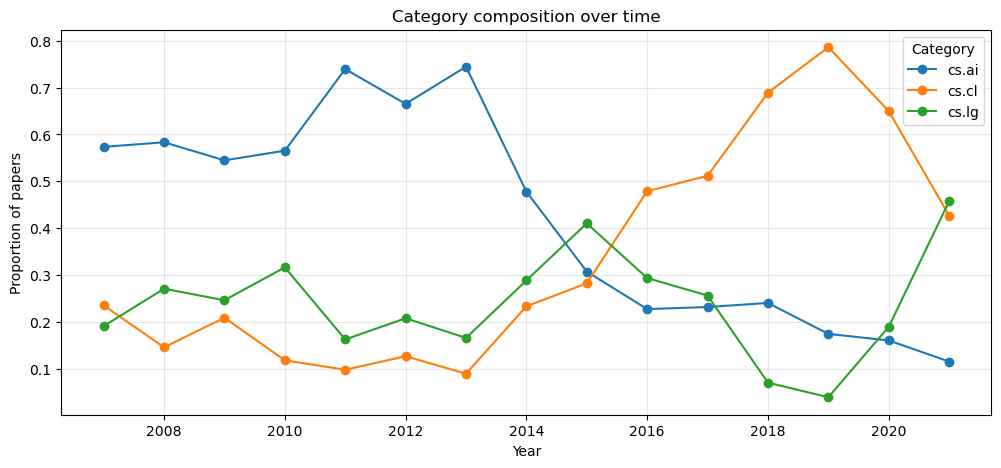

In [58]:
# Does category composition change over time?
cat_by_year = df_analysis.groupby(['year', 'cat_combo']).size().unstack(fill_value=0)
cat_by_year_pct = cat_by_year.div(cat_by_year.sum(axis=1), axis=0)

cat_by_year_pct.plot(figsize=(12, 5), marker='o')
plt.title('Category composition over time')
plt.ylabel('Proportion of papers')
plt.xlabel('Year')
plt.legend(title='Category')
plt.grid(True, alpha=0.3)
# plt.savefig("outputs/figures/category_composition_over_time.png", dpi=150)
plt.show()

_PC1 separates NLP-vocabulary-heavy papers (cs.CL) from algorithm/systems papers (cs.LG, cs.AI). Temporal drift along PC1 therefore reflects both genuine topic evolution and shifts in category composition within the corpus. These two effects cannot be fully disentangled in this representation, which is a limitation of the TF-IDF approach on a multi-category corpus — and one motivation for comparing against sentence embeddings, which capture meaning more independently of surface vocabulary._

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_7475/4291940472.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(years))
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_7475/4291940472.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(years))
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_7475/4291940472.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  

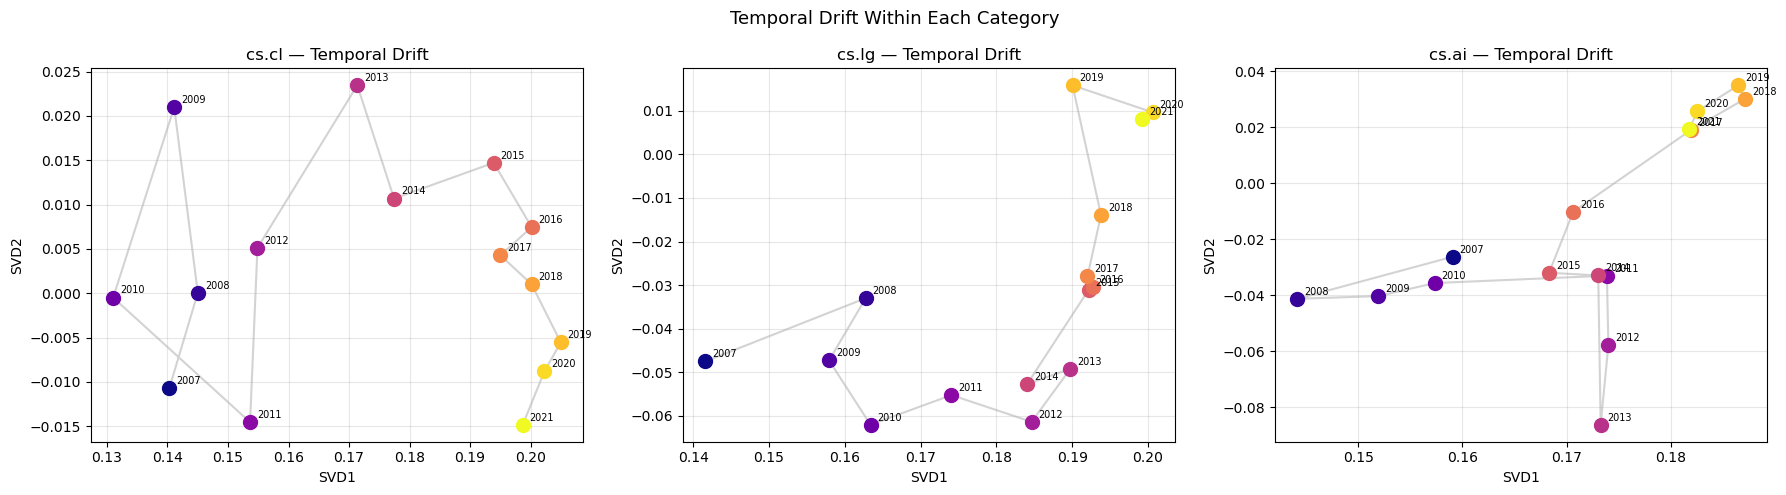

In [61]:
from sklearn.decomposition import TruncatedSVD

results = []

for cat in ['cs.cl', 'cs.lg', 'cs.ai']:
    subset = df_analysis[df_analysis['cat_combo'] == cat].copy()
    
    if len(subset) < 50:
        continue
    
    # Fit TF-IDF on this category only
    tfidf_cat = TfidfVectorizer(
        max_features=3000,
        stop_words="english",
        ngram_range=(1, 2)
    )
    X = tfidf_cat.fit_transform(subset['abstract'])
    
    # TruncatedSVD on this category only
    svd = TruncatedSVD(n_components=2, random_state=42)
    coords = svd.fit_transform(X)
    
    subset['svd_x'] = coords[:, 0]
    subset['svd_y'] = coords[:, 1]
    subset['category'] = cat
    results.append(subset)

df_by_cat = pd.concat(results).reset_index(drop=True)

# Now plot centroids per category — temporal drift within each
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cat in zip(axes, ['cs.cl', 'cs.lg', 'cs.ai']):
    subset = df_by_cat[df_by_cat['category'] == cat]
    centroids = subset.groupby('year')[['svd_x', 'svd_y']].mean()
    
    years = centroids.index.tolist()
    cmap = cm.get_cmap('plasma', len(years))
    
    ax.plot(centroids['svd_x'], centroids['svd_y'],
            color='lightgray', linewidth=1.5, zorder=1)
    
    for i, year in enumerate(years):
        x, y = centroids.loc[year]
        ax.scatter(x, y, c=[cmap(i)], s=100, zorder=2)
        ax.annotate(str(year), (x, y),
                    textcoords="offset points",
                    xytext=(5, 3), fontsize=7)
    
    ax.set_title(f'{cat} — Temporal Drift')
    ax.set_xlabel('SVD1')
    ax.set_ylabel('SVD2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Temporal Drift Within Each Category', fontsize=13)
plt.tight_layout()
# plt.savefig("../outputs/figures/temporal_drift_by_category.png", dpi=150)
plt.show()

## Build Sentence-BERT embeddings

In [20]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [21]:
texts = df["abstract"].tolist()

X_embed = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True
)

print("Embedding shape:", X_embed.shape)

Batches:   0%|          | 0/776 [00:00<?, ?it/s]

Embedding shape: (24806, 384)
